# Predição de Desempenho Acadêmico no EBTT-UFPB
## Aluno, Professor e Currículo como Preditores de Sucesso

**Disciplina:** Aprendizagem de Máquina Supervisionada  
**Dados:** SIGAA/UFPB — CPT-ETS e CAVN  
**Entrega:** Parcial — Análise Exploratória + Experimentos Iniciais de Modelagem

---

### Estrutura do Notebook
1. Configuração do Ambiente
2. Carregamento e Inspeção dos Dados
3. Integração das Tabelas
4. Definição da Variável-Alvo
5. Análise Exploratória de Dados (EDA)
6. Pré-processamento e Feature Engineering
7. Modelagem Supervisionada
8. Comparação dos Modelos
9. Interpretabilidade
10. Conclusões Parciais e Próximos Passos

## Definição do Problema

Este projeto tem como objetivo desenvolver um modelo de machine learning capaz de **predizer o desempenho acadêmico dos discentes no âmbito do EBTT-UFPB**, considerando o ecossistema de aprendizagem composto por três dimensões principais: aluno, professor e currículo.

Trata-se de um problema de **classificação**, no qual se busca identificar padrões que permitam classificar os estudantes quanto ao seu desempenho acadêmico (por exemplo, aprovação ou reprovação em componentes curriculares).

Para isso, foram integradas diferentes bases de dados institucionais, incluindo:
- Informações dos discentes (perfil acadêmico e histórico)
- Dados de matrículas (trajetória acadêmica)
- Componentes curriculares (estrutura das disciplinas)
- Cursos (organização curricular)
- Docentes (características dos professores)

A hipótese central do projeto é que o desempenho acadêmico não depende apenas do aluno, mas é influenciado pela interação entre fatores individuais, características do corpo docente e estrutura curricular.

Dessa forma, o modelo proposto busca capturar essas relações para gerar previsões que possam subsidiar ações institucionais voltadas à melhoria do desempenho e redução de riscos acadêmicos.

In [32]:
with open('.gitignore', 'w') as f:
    f.write('dados/\n*.parquet\n')

## 1. Configuração do Ambiente

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Ambiente configurado.')
import sklearn; print(f'sklearn {sklearn.__version__} | pandas {pd.__version__}')

Ambiente configurado.
sklearn 1.6.1 | pandas 2.2.2


## 2. Carregamento e Inspeção dos Dados

In [4]:
DATA_PATH = '/content/'

discentes   = pd.read_parquet(DATA_PATH + 'discentes.parquet')
docentes    = pd.read_parquet(DATA_PATH + 'docentes.parquet')
matriculas  = pd.read_parquet(DATA_PATH + 'matriculas.parquet')
componentes = pd.read_parquet(DATA_PATH + 'componentes.parquet')
cursos      = pd.read_parquet(DATA_PATH + 'cursos.parquet')

datasets = {
    'discentes': discentes, 'docentes': docentes,
    'matriculas': matriculas, 'componentes': componentes, 'cursos': cursos
}

print(f'{"Dataset":<15} {"Linhas":>10} {"Colunas":>10}')
print('-' * 38)
for nome, df in datasets.items():
    print(f'{nome:<15} {df.shape[0]:>10,} {df.shape[1]:>10}')

Dataset             Linhas    Colunas
--------------------------------------
discentes            7,707         21
docentes               348         11
matriculas         426,753          5
componentes            998         22
cursos               1,310         19


In [5]:
for nome, df in datasets.items():
    print(f'\n{"="*55}\n  {nome.upper()}\n{"="*55}')
    print(df.dtypes.to_string())
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print('\n  Valores nulos:')
    if len(nulos):
        for col, n in nulos.items():
            print(f'    {col}: {n} ({n/len(df)*100:.1f}%)')
    else:
        print('    Nenhum.')
    display(df.head(3))


  DISCENTES
id_discente                     object
sexo                            object
estado_civil                    object
raca_declarada                  object
discente_nivel                  object
id_curso                         int64
id_curriculo                   float64
id_estrutura_curricular          int64
ano_ingresso                     int64
periodo_ingresso                 int64
status_discente                 object
forma_ingresso                  object
quantidade_membros_familia     float64
ch_integralizada               float64
ch_pendente                    float64
media_geral                    float64
ano_nascimento                 float64
faixa_renda_familiar          category
uf_titulo_eleitor_pb           float64
uf_naturalidade_pb             float64
pais_origem_br                 float64

  Valores nulos:
    id_curriculo: 7707 (100.0%)
    quantidade_membros_familia: 5587 (72.5%)
    ch_integralizada: 1871 (24.3%)
    ch_pendente: 1871 (24.3%)
    medi

,id_discente,sexo,estado_civil,raca_declarada,discente_nivel,id_curso,id_curriculo,id_estrutura_curricular,ano_ingresso,periodo_ingresso,...,forma_ingresso,quantidade_membros_familia,ch_integralizada,ch_pendente,media_geral,ano_nascimento,faixa_renda_familiar,uf_titulo_eleitor_pb,uf_naturalidade_pb,pais_origem_br
0,1169287803480640,M,Solteiro(a),Nao_informado,T,2558681,NaN,25587020,2016,2,...,PROCESSO SELETIVO,NaN,68.0,1432.0,0.93,1994.0,NaN,NaN,1.0,1.0
1,8959954670178323,F,Solteiro(a),Nao_informado,T,1958830,NaN,23647550,2016,2,...,PROCESSO SELETIVO,NaN,NaN,NaN,0.00,1997.0,NaN,1.0,1.0,1.0
2,9718041069456731,F,Solteiro(a),Negra,T,31496451,NaN,319171030,2023,1,...,PROCESSO SELETIVO,NaN,240.0,0.0,9.05,1970.0,NaN,NaN,1.0,1.0



  DOCENTES
id_pessoa              object
sexo                   object
tipo_vinculo           object
sigla_departamento     object
nome_departamento      object
sigla_centro           object
nome_centro            object
situacao               object
cargo                  object
ano_admissao          float64
ano_desligamento      float64

  Valores nulos:
    ano_admissao: 6 (1.7%)
    ano_desligamento: 131 (37.6%)


,id_pessoa,sexo,tipo_vinculo,sigla_departamento,nome_departamento,sigla_centro,nome_centro,situacao,cargo,ano_admissao,ano_desligamento
0,5986743761005378,F,DE,CPT-DRPAS,"CPT-ETS - DEPARTAMENTO DE REGISTRO, PROMOÇÃO E...",CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,Colaborador PCCTAE,PROFESSOR ENS BASICO TECN TECNOLOGICO,2020.0,2024.0
1,6486331404889296,M,DE,PROEX,PRÓ-REITORIA DE EXTENSÃO (PROEX),UFPB.,UNIVERSIDADE FEDERAL DA PARAÍBA,Colaborador PCCTAE,PROFESSOR ENS BASICO TECN TECNOLOGICO,2022.0,2025.0
2,9067115124174644,F,DE,CCHSA-DCBS,CCHSA - DEPARTAMENTO DE CIÊNCIAS BÁSICAS E SOC...,CCHSA,CENTRO DE CIÊNCIAS HUMANAS SOCIAIS E AGRÁRIAS ...,Colaborador PCCTAE,PROF DO ENSINO BASICO TEC TECNOLOGICO,2018.0,2019.0



  MATRICULAS
id_discente      object
id_disciplina     int64
ano              object
periodo          object
situacao         object

  Valores nulos:
    Nenhum.


,id_discente,id_disciplina,ano,periodo,situacao
0,9519063299906826,25772,2020,1,APROVADO
1,9519063299906826,25774,2020,1,REPROVADO
2,9519063299906826,25773,2020,1,REPROVADO



  COMPONENTES
id_disciplina                            int64
id_detalhe                               int64
nome                                    object
ch_aula                                  int64
ch_laboratorio                           int64
ch_total                                 int64
cr_aula                                  int64
cr_laboratorio                           int64
cr_estagio                               int64
ch_ead                                   int64
sigla_departamento                      object
nivel_componente_curricular             object
sigla_academica                         object
nome_departamento                       object
sigla_centro                            object
nome_centro                             object
qtd_max_matriculas                       int64
codigo_componente_curricular            object
nome_componete_curricular               object
descricao_tipo_componente_curricular    object
excluir_avaliacao_institucional           boo

,id_disciplina,id_detalhe,nome,ch_aula,ch_laboratorio,ch_total,cr_aula,cr_laboratorio,cr_estagio,ch_ead,...,sigla_academica,nome_departamento,sigla_centro,nome_centro,qtd_max_matriculas,codigo_componente_curricular,nome_componete_curricular,descricao_tipo_componente_curricular,excluir_avaliacao_institucional,ativo
0,18066,2364646,NOÇÕES DE PRIMEIROS SOCORROS,30,0,30,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0001,NOÇÕES DE PRIMEIROS SOCORROS,DISCIPLINA,False,True
1,18069,2364635,NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA,40,0,40,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0002,NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA,DISCIPLINA,False,True
2,18070,2741620,"NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNO...",10,30,40,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0003,"NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNO...",DISCIPLINA,False,True



  CURSOS
id_curso                            int64
curso_nome                         object
curso_unidade_nome                 object
campus                             object
curso_ativo                          bool
curso_grande_area_conhecimento    float64
id_estrutura_curricular             int64
codigo_emec                       float64
turno_estrutura_curricular         object
periodo                            object
estrutura_curricular_ativo           bool
carga_horaria                       int64
id_modulo                           int64
codigo                             object
modulo                             object
carga_horaria_modulo                int64
ordem_oferta_modulo               float64
id_disciplina                       int64
codigo_disciplina                  object

  Valores nulos:
    curso_grande_area_conhecimento: 1310 (100.0%)
    codigo_emec: 1310 (100.0%)
    ordem_oferta_modulo: 617 (47.1%)


,id_curso,curso_nome,curso_unidade_nome,campus,curso_ativo,curso_grande_area_conhecimento,id_estrutura_curricular,codigo_emec,turno_estrutura_curricular,periodo,estrutura_curricular_ativo,carga_horaria,id_modulo,codigo,modulo,carga_horaria_modulo,ordem_oferta_modulo,id_disciplina,codigo_disciplina
0,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,27342,CAVN00112
1,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,28736,CAVN00165
2,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,28737,CAVN00166


In [6]:
print('Situacoes nas matriculas:')
print(matriculas['situacao'].value_counts().to_string())
print(f'\nAnos: {sorted(matriculas["ano"].unique())}')

Situacoes nas matriculas:
situacao
APROVADO               318849
CANCELADO               32931
REPROVADO               25175
EXCLUIDA                14846
REP. MEDIA E FALTA      12986
MATRICULADO             11770
TRANCADO                 4560
APROVEITADO              4197
DISPENSADO                470
REP. FALTA                411
DESISTENCIA               322
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7

Anos: ['2004', '2005', '2006', '2009', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


## 3. Integração das Tabelas

```
matriculas
  ├── id_discente   ──► discentes   (perfil do aluno)
  └── id_disciplina ──► componentes (currículo)
                            └── sigla_departamento ──► docentes (agregado por dept.)
```

In [8]:
# Agrega perfil docente por departamento
agg_map = {'id_pessoa': 'count', 'ano_admissao': 'median'}
if 'sexo' in docentes.columns:
    docentes['_fem'] = (docentes['sexo'] == 'FEMININO').astype(int)
    agg_map['_fem'] = 'mean'
if 'tipo_vinculo' in docentes.columns:
    docentes['_efetivo'] = docentes['tipo_vinculo'].str.contains('EFETIVO', na=False).astype(int)
    agg_map['_efetivo'] = 'mean'

docentes_dept = docentes.groupby('sigla_departamento').agg(agg_map).reset_index()
rename = {'id_pessoa': 'total_docentes', '_fem': 'prop_feminino',
          '_efetivo': 'prop_efetivo', 'ano_admissao': 'ano_admissao_medio'}
docentes_dept.rename(columns=rename, inplace=True)

print(f'Departamentos: {len(docentes_dept)}')
display(docentes_dept.head())

Departamentos: 44


,sigla_departamento,total_docentes,ano_admissao_medio,prop_feminino,prop_efetivo
0,CCA-DC,14,1962.0,0.0,0.0
1,CCA-DCFS,1,1984.0,0.0,0.0
2,CCA-DZOOT,1,2008.0,0.0,0.0
3,CCEN-DQ,1,1984.0,0.0,0.0
4,CCHLA - DLCV,1,1981.0,0.0,0.0


In [9]:
COLS_DISC = [c for c in [
    'id_discente', 'sexo', 'raca_declarada', 'estado_civil',
    'faixa_renda_familiar', 'ano_ingresso', 'periodo_ingresso',
    'forma_ingresso', 'quantidade_membros_familia',
    'ch_integralizada', 'ch_pendente', 'media_geral',
    'ano_nascimento', 'discente_nivel', 'id_curso',
    'uf_titulo_eleitor_pb', 'uf_naturalidade_pb'
] if c in discentes.columns]

COLS_COMP = [c for c in [
    'id_disciplina', 'ch_total', 'ch_aula', 'ch_laboratorio',
    'ch_ead', 'nivel_componente_curricular', 'sigla_departamento',
    'nome_centro', 'qtd_max_matriculas', 'descricao_tipo_componente_curricular'
] if c in componentes.columns]

df = (
    matriculas
    .merge(discentes[COLS_DISC], on='id_discente', how='left')
    .merge(componentes[COLS_COMP], on='id_disciplina', how='left')
    .merge(docentes_dept, on='sigla_departamento', how='left')
)

print(f'Dataset integrado: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

Dataset integrado: 426,780 linhas x 34 colunas


## 4. Definição da Variável-Alvo

| Valor | Classe | Situações |
|-------|--------|-----------|
| 1 | **Sucesso** | APROVADO, APROV. C/ DISTINÇÃO, DISPENSADO |
| 0 | **Insucesso** | REPROVADO, REPROVADO POR FALTA, CANCELADO, TRANCADO |

In [10]:
SITUACOES_SUCESSO = [
    'APROVADO', 'APROV. C/ DISTINÇÃO', 'DISPENSADO',
    'APROVADO POR NOTA', 'APROV. C/ DISTINCAO'
]
SITUACOES_INSUCESSO = [
    'REPROVADO', 'REPROVADO POR FALTA', 'CANCELADO',
    'TRANCADO', 'TRANSFERIDO', 'JUBILADO'
]

situacoes_finais = SITUACOES_SUCESSO + SITUACOES_INSUCESSO
df_modelo = df[df['situacao'].isin(situacoes_finais)].copy()
df_modelo['target'] = df_modelo['situacao'].isin(SITUACOES_SUCESSO).astype(int)

vc = df_modelo['target'].value_counts()
print(f'Total (situacoes finais): {len(df_modelo):,}')
print(f'Sucesso   (1): {vc.get(1,0):,} ({vc.get(1,0)/len(df_modelo)*100:.1f}%)')
print(f'Insucesso (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df_modelo)*100:.1f}%)')
ratio = vc.get(1,0) / max(vc.get(0,0), 1)
print(f'Razão S/I: {ratio:.2f}' + (' ⚠️ desbalanceado' if ratio > 3 else ''))

Total (situacoes finais): 382,239
Sucesso   (1): 319,352 (83.5%)
Insucesso (0): 62,887 (16.5%)
Razão S/I: 5.08 ⚠️ desbalanceado


## 5. Análise Exploratória de Dados (EDA)

### 5.1 Dimensão Aluno

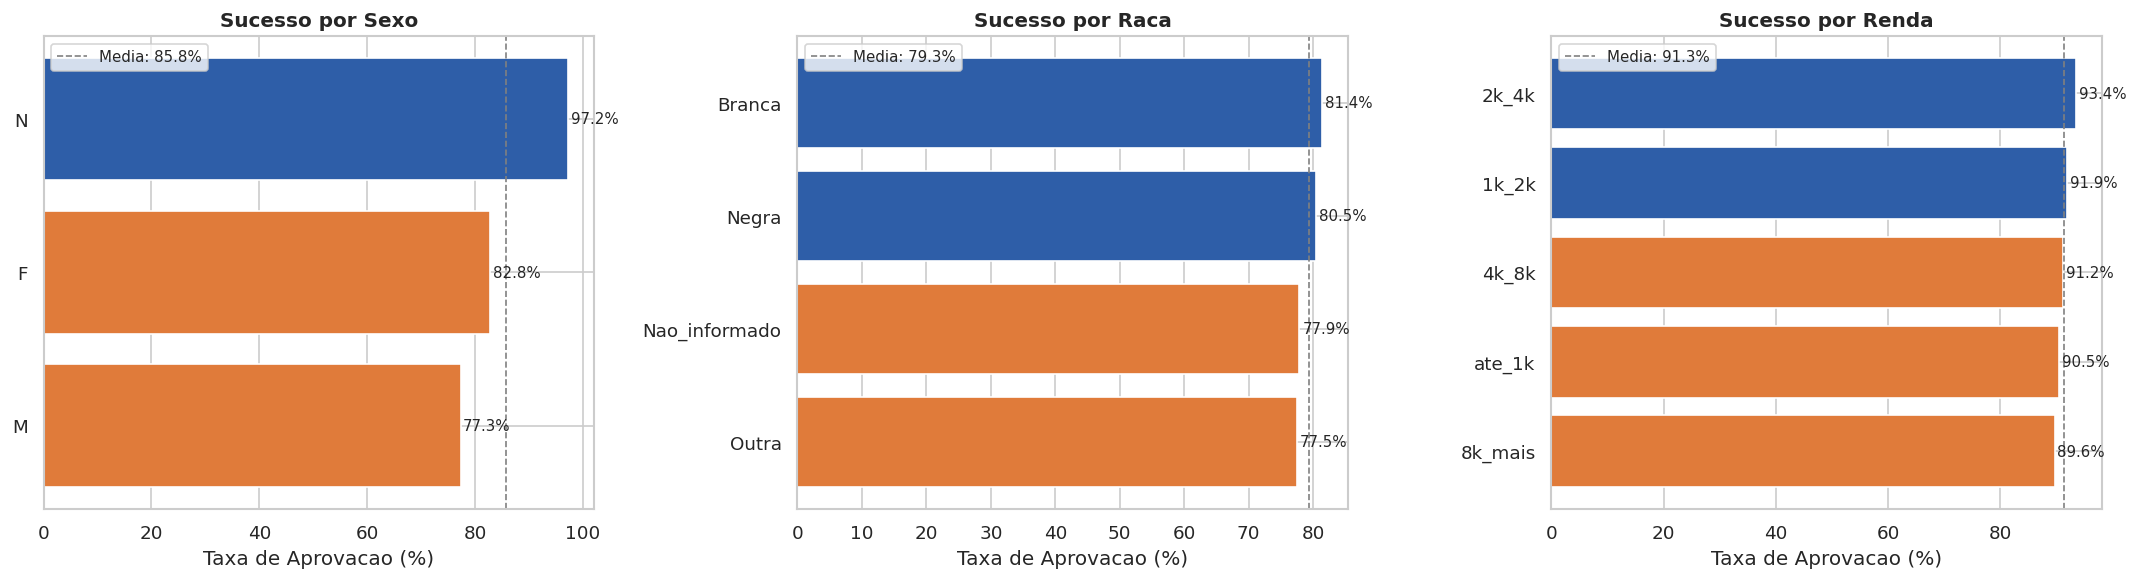

In [11]:
cols_perfil = [c for c in ['sexo', 'raca_declarada', 'faixa_renda_familiar'] if c in df_modelo.columns]
if cols_perfil:
    fig, axes = plt.subplots(1, len(cols_perfil), figsize=(6*len(cols_perfil), 5))
    if len(cols_perfil) == 1: axes = [axes]
    titulos = {'sexo':'Sucesso por Sexo','raca_declarada':'Sucesso por Raca','faixa_renda_familiar':'Sucesso por Renda'}
    for ax, col in zip(axes, cols_perfil):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--', linewidth=1, label=f'Media: {taxa.mean():.1f}%')
        ax.set_xlabel('Taxa de Aprovacao (%)')
        ax.set_title(titulos.get(col, col), fontweight='bold')
        ax.legend(fontsize=9)
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig1_taxa_sucesso_perfil_aluno.png', dpi=150, bbox_inches='tight')
    plt.show()

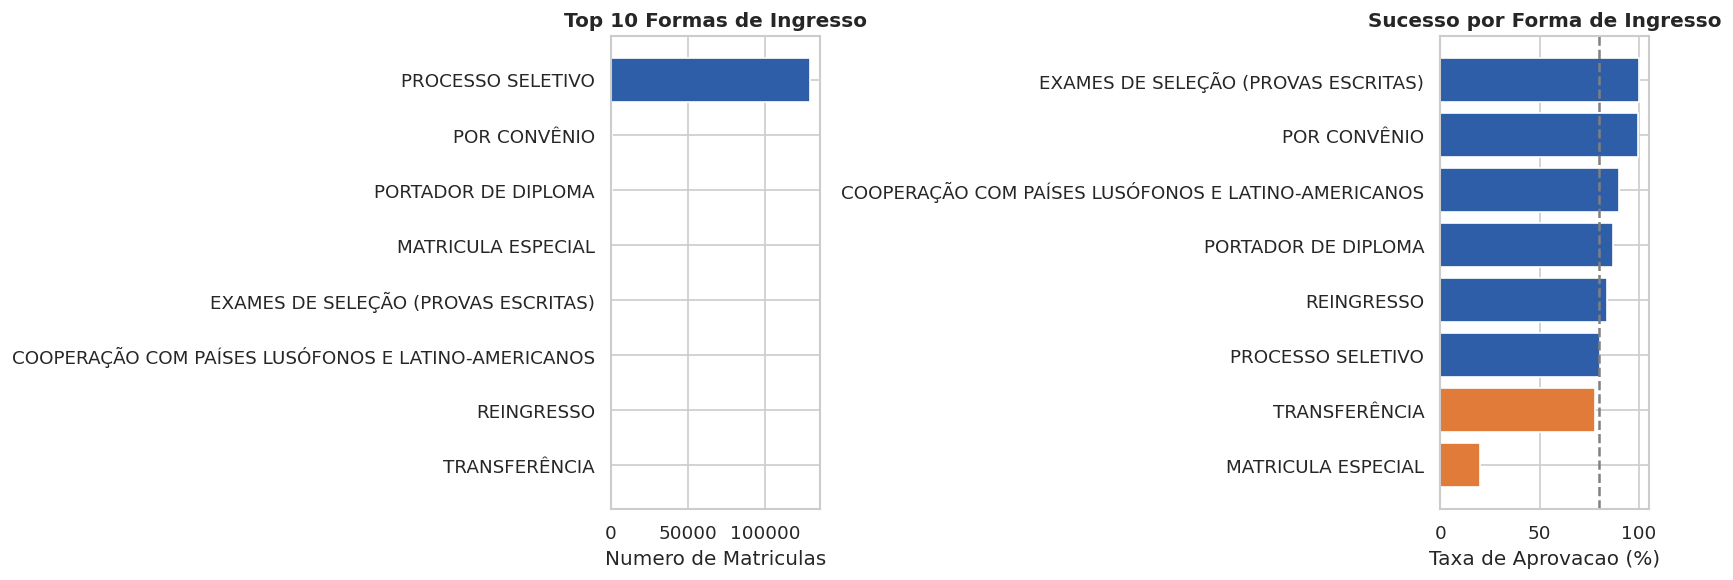

In [12]:
if 'forma_ingresso' in df_modelo.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    forma_counts = df_modelo['forma_ingresso'].value_counts().head(10)
    axes[0].barh(forma_counts.index[::-1], forma_counts.values[::-1], color='#2E5EA8')
    axes[0].set_xlabel('Numero de Matriculas')
    axes[0].set_title('Top 10 Formas de Ingresso', fontweight='bold')
    taxa_ing = df_modelo.groupby('forma_ingresso')['target'].mean().sort_values().tail(10) * 100
    colors = ['#2E5EA8' if v >= taxa_ing.mean() else '#E07B3A' for v in taxa_ing.values]
    axes[1].barh(taxa_ing.index, taxa_ing.values, color=colors)
    axes[1].axvline(taxa_ing.mean(), color='gray', linestyle='--')
    axes[1].set_xlabel('Taxa de Aprovacao (%)')
    axes[1].set_title('Sucesso por Forma de Ingresso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig2_forma_ingresso.png', dpi=150, bbox_inches='tight')
    plt.show()

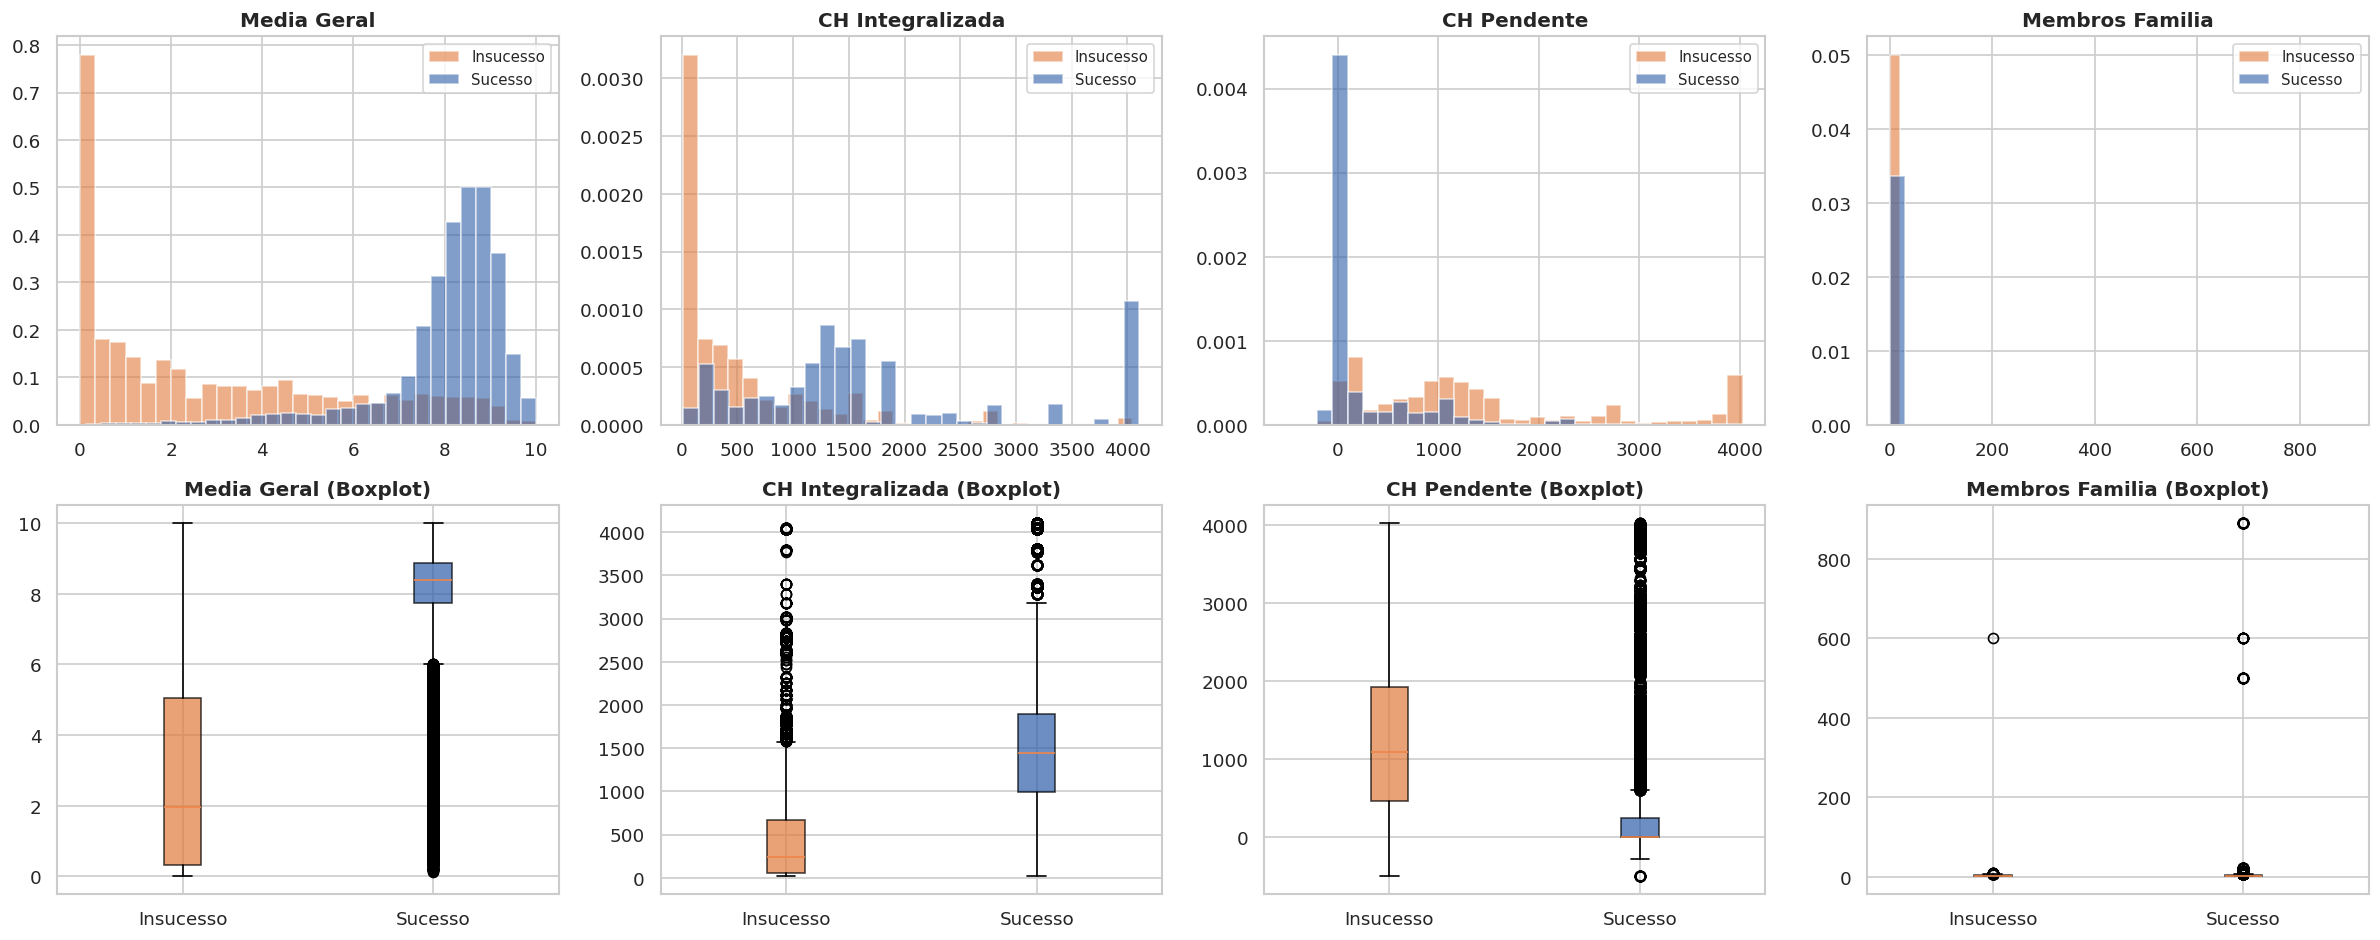

In [13]:
num_aluno = [(c, l) for c, l in [
    ('media_geral','Media Geral'),('ch_integralizada','CH Integralizada'),
    ('ch_pendente','CH Pendente'),('quantidade_membros_familia','Membros Familia')
] if c in df_modelo.columns]

if num_aluno:
    cols_p, labs_p = zip(*num_aluno)
    n = len(cols_p)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(2,1)
    for i, (col, label) in enumerate(zip(cols_p, labs_p)):
        for cls, color, lbl in [(0,'#E07B3A','Insucesso'),(1,'#2E5EA8','Sucesso')]:
            subset = df_modelo[df_modelo['target']==cls][col].dropna()
            axes[0,i].hist(subset, bins=30, alpha=0.6, color=color, label=lbl, density=True)
        axes[0,i].set_title(label, fontweight='bold'); axes[0,i].legend(fontsize=9)
        data = [df_modelo[df_modelo['target']==cls][col].dropna() for cls in [0,1]]
        bp = axes[1,i].boxplot(data, patch_artist=True, labels=['Insucesso','Sucesso'])
        for patch, color in zip(bp['boxes'], ['#E07B3A','#2E5EA8']):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        axes[1,i].set_title(f'{label} (Boxplot)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig3_distribuicoes_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()

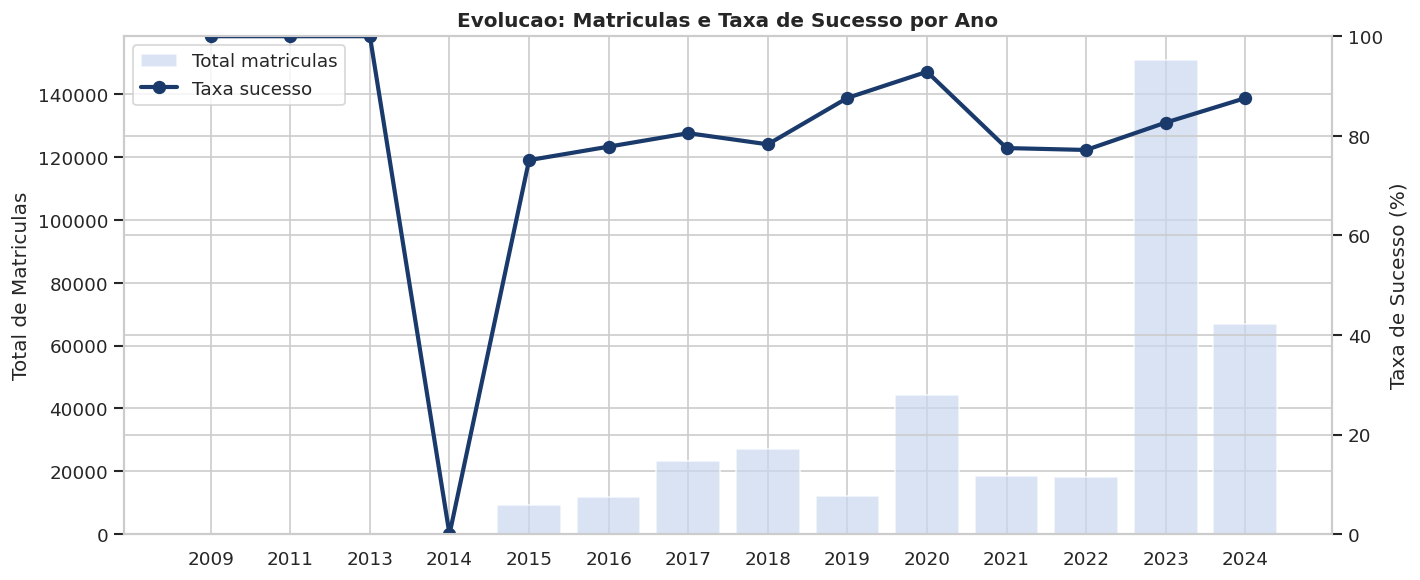

In [14]:
if 'ano' in df_modelo.columns:
    taxa_ano = df_modelo.groupby('ano')['target'].agg(['mean','count']).reset_index()
    taxa_ano.columns = ['ano','taxa_sucesso','total']
    taxa_ano['taxa_sucesso'] *= 100
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.bar(taxa_ano['ano'], taxa_ano['total'], color='#CBD8EF', alpha=0.7, label='Total matriculas')
    ax2.plot(taxa_ano['ano'], taxa_ano['taxa_sucesso'], 'o-', color='#1A3A6B', lw=2.5, ms=7, label='Taxa sucesso')
    ax1.set_ylabel('Total de Matriculas'); ax2.set_ylabel('Taxa de Sucesso (%)'); ax2.set_ylim(0,100)
    l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc='upper left')
    plt.title('Evolucao: Matriculas e Taxa de Sucesso por Ano', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig4_evolucao_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.2 Dimensão Currículo

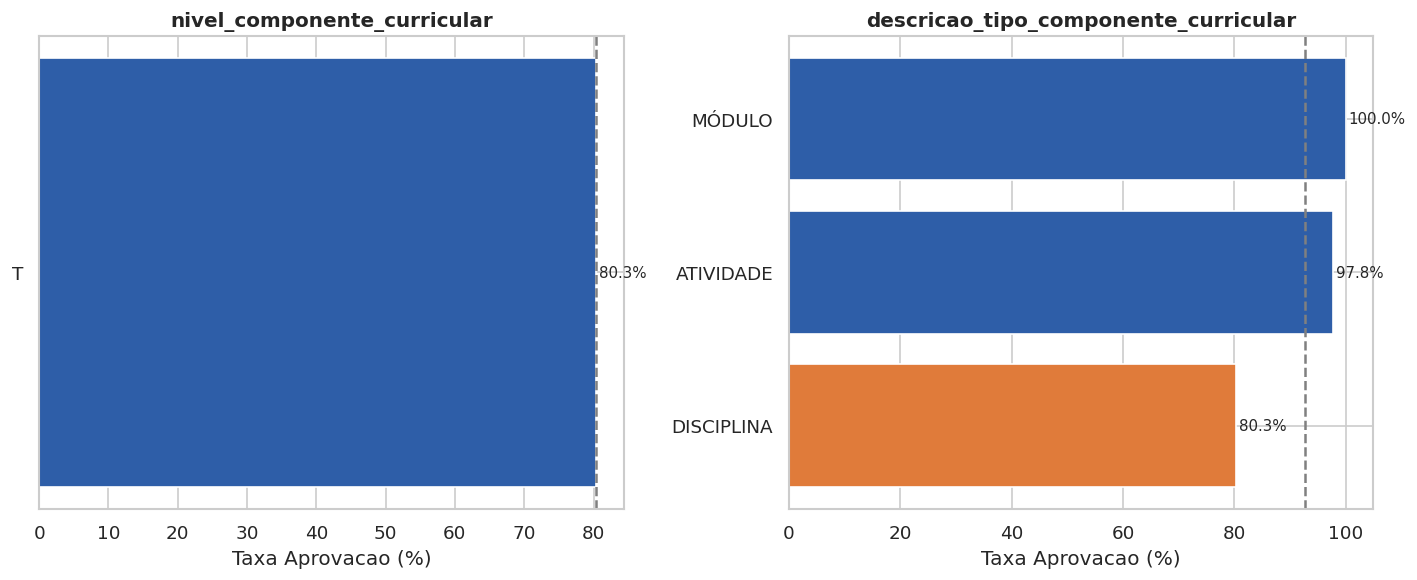

In [15]:
cols_curr = [c for c in ['campus','nivel_componente_curricular','descricao_tipo_componente_curricular'] if c in df_modelo.columns]
if cols_curr:
    fig, axes = plt.subplots(1, len(cols_curr), figsize=(6*len(cols_curr), 5))
    if len(cols_curr) == 1: axes = [axes]
    for ax, col in zip(axes, cols_curr):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        taxa = taxa.head(12)
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--')
        ax.set_xlabel('Taxa Aprovacao (%)'); ax.set_title(col, fontweight='bold')
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig5_taxa_sucesso_curriculo.png', dpi=150, bbox_inches='tight')
    plt.show()

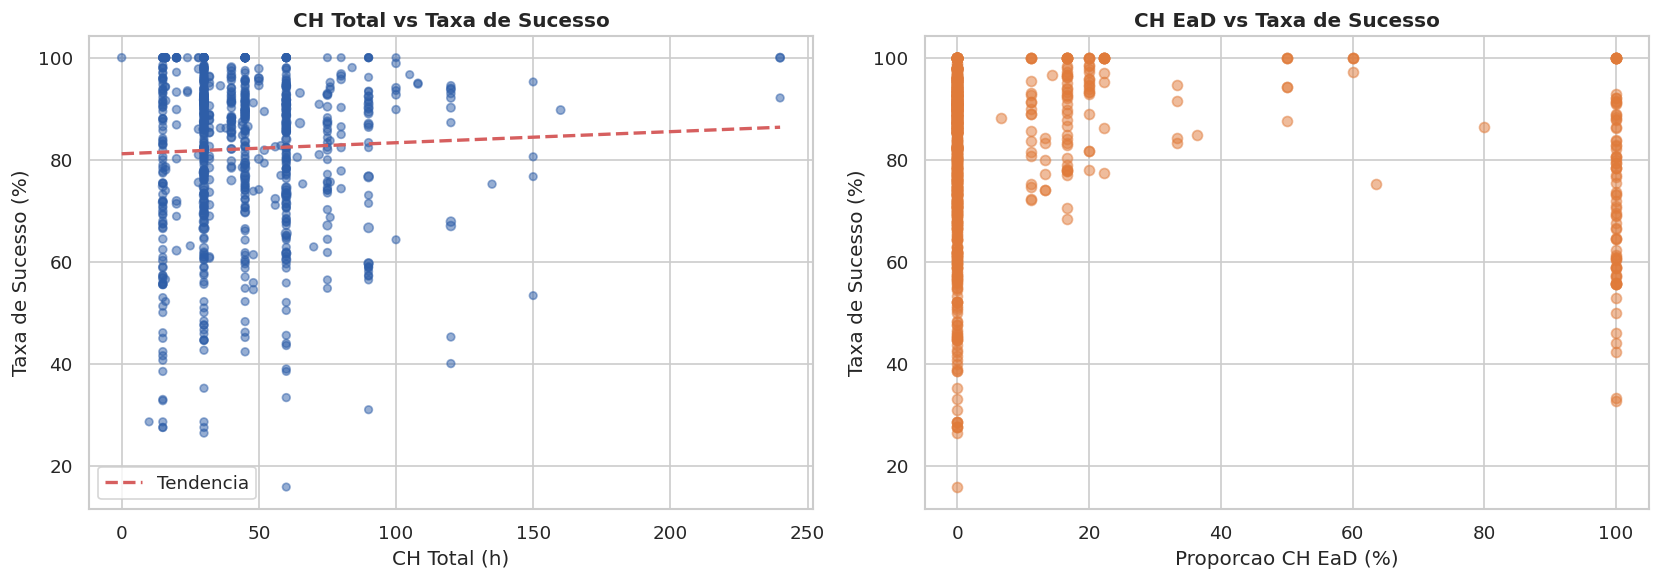

In [16]:
if {'id_disciplina','ch_total','ch_ead'}.issubset(df_modelo.columns):
    comp_taxa = df_modelo.groupby('id_disciplina').agg(
        taxa_sucesso=('target','mean'), ch_total=('ch_total','first'),
        ch_ead=('ch_ead','first'), total=('target','count')
    ).reset_index()
    comp_taxa = comp_taxa[comp_taxa['total'] >= 5]
    comp_taxa['prop_ead'] = comp_taxa['ch_ead'] / (comp_taxa['ch_total'] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(comp_taxa['ch_total'], comp_taxa['taxa_sucesso']*100, alpha=0.5,
                    s=comp_taxa['total']/comp_taxa['total'].max()*200+20, color='#2E5EA8')
    valid = comp_taxa[['ch_total','taxa_sucesso']].dropna()
    if len(valid) > 1:
        p = np.poly1d(np.polyfit(valid['ch_total'], valid['taxa_sucesso']*100, 1))
        xl = np.linspace(valid['ch_total'].min(), valid['ch_total'].max(), 100)
        axes[0].plot(xl, p(xl), 'r--', lw=2, label='Tendencia')
    axes[0].set_xlabel('CH Total (h)'); axes[0].set_ylabel('Taxa de Sucesso (%)')
    axes[0].set_title('CH Total vs Taxa de Sucesso', fontweight='bold'); axes[0].legend()

    axes[1].scatter(comp_taxa['prop_ead']*100, comp_taxa['taxa_sucesso']*100, alpha=0.5, color='#E07B3A')
    axes[1].set_xlabel('Proporcao CH EaD (%)'); axes[1].set_ylabel('Taxa de Sucesso (%)')
    axes[1].set_title('CH EaD vs Taxa de Sucesso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig6_ch_vs_taxa.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.3 Dimensão Professor

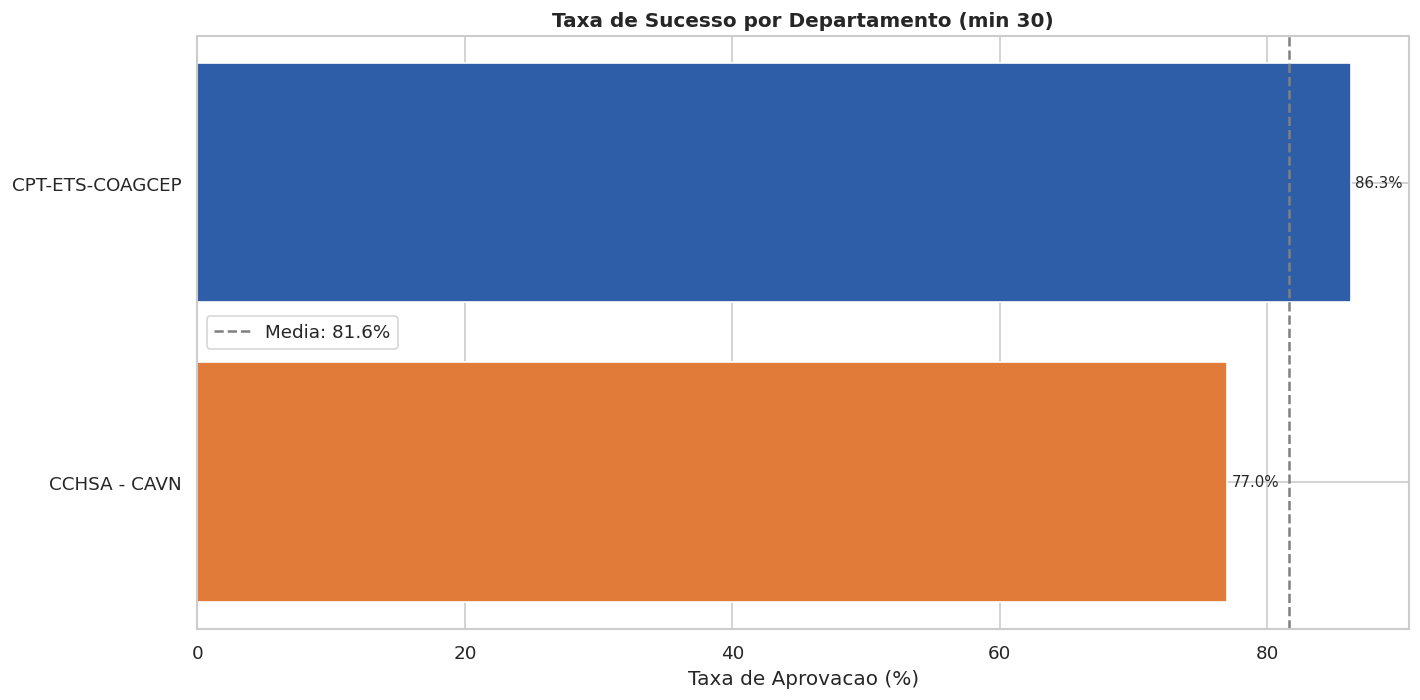

In [17]:
if 'sigla_departamento' in df_modelo.columns:
    taxa_dept = df_modelo.groupby('sigla_departamento').agg(
        taxa_sucesso=('target','mean'), total=('target','count')
    ).reset_index()
    taxa_dept = taxa_dept[taxa_dept['total'] >= 30].sort_values('taxa_sucesso')
    taxa_dept['taxa_sucesso'] *= 100
    fig, ax = plt.subplots(figsize=(12, max(6, len(taxa_dept)*0.4)))
    colors = ['#2E5EA8' if v >= taxa_dept['taxa_sucesso'].mean() else '#E07B3A' for v in taxa_dept['taxa_sucesso']]
    bars = ax.barh(taxa_dept['sigla_departamento'], taxa_dept['taxa_sucesso'], color=colors)
    ax.axvline(taxa_dept['taxa_sucesso'].mean(), color='gray', linestyle='--', lw=1.5,
               label=f'Media: {taxa_dept["taxa_sucesso"].mean():.1f}%')
    ax.set_xlabel('Taxa de Aprovacao (%)'); ax.set_title('Taxa de Sucesso por Departamento (min 30)', fontweight='bold')
    ax.legend()
    for bar, val in zip(bars, taxa_dept['taxa_sucesso']):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig7_taxa_departamento.png', dpi=150, bbox_inches='tight')
    plt.show()

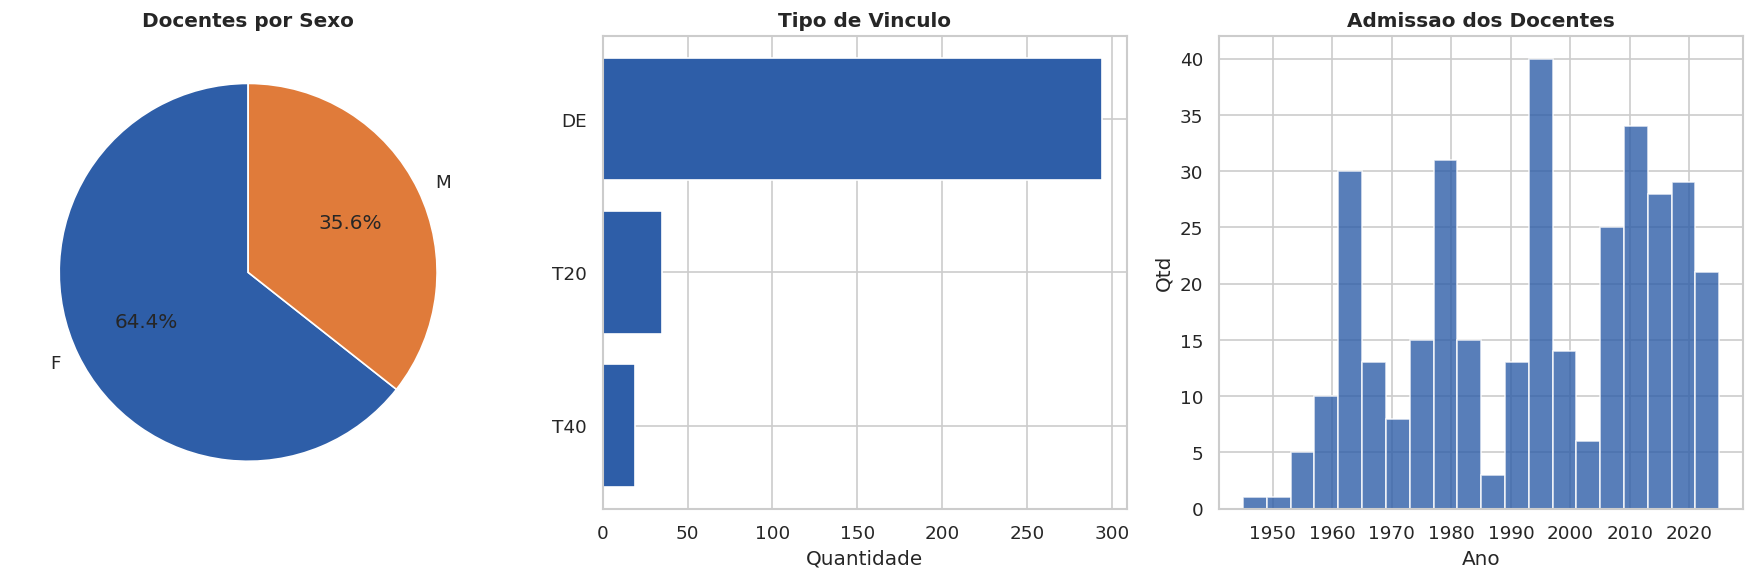

Total docentes: 348


In [18]:
cols_doc = [c for c in ['sexo','tipo_vinculo','ano_admissao'] if c in docentes.columns]
if cols_doc:
    fig, axes = plt.subplots(1, len(cols_doc), figsize=(5*len(cols_doc), 5))
    if len(cols_doc) == 1: axes = [axes]
    for i, col in enumerate(cols_doc):
        ax = axes[i]
        if col == 'sexo':
            vc2 = docentes['sexo'].value_counts()
            ax.pie(vc2.values, labels=vc2.index, autopct='%1.1f%%', colors=['#2E5EA8','#E07B3A'], startangle=90)
            ax.set_title('Docentes por Sexo', fontweight='bold')
        elif col == 'tipo_vinculo':
            vc2 = docentes['tipo_vinculo'].value_counts().head(6)
            ax.barh(vc2.index[::-1], vc2.values[::-1], color='#2E5EA8')
            ax.set_xlabel('Quantidade'); ax.set_title('Tipo de Vinculo', fontweight='bold')
        elif col == 'ano_admissao':
            docentes['ano_admissao'].dropna().hist(bins=20, color='#2E5EA8', alpha=0.8, ax=ax)
            ax.set_xlabel('Ano'); ax.set_ylabel('Qtd'); ax.set_title('Admissao dos Docentes', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig8_perfil_docente.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Total docentes: {len(docentes)}')

### 5.4 Análise da Variável-Alvo

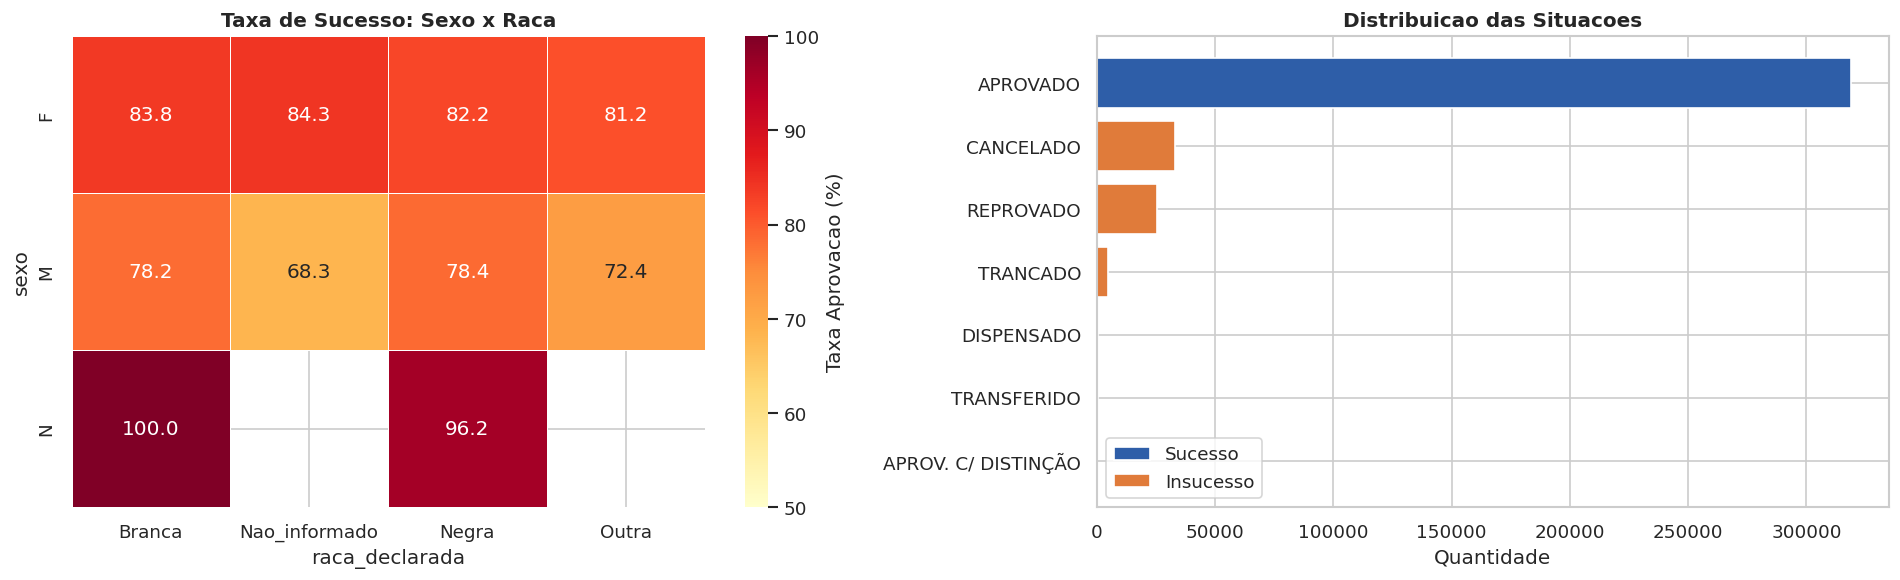

In [19]:
if {'sexo','raca_declarada'}.issubset(df_modelo.columns):
    pivot = df_modelo.groupby(['sexo','raca_declarada'])['target'].mean().unstack() * 100
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
                vmin=50, vmax=100, cbar_kws={'label': 'Taxa Aprovacao (%)'})
    axes[0].set_title('Taxa de Sucesso: Sexo x Raca', fontweight='bold')
    sit_counts = df_modelo['situacao'].value_counts()
    colors_map = ['#2E5EA8' if s in SITUACOES_SUCESSO else '#E07B3A' for s in sit_counts.index]
    axes[1].barh(sit_counts.index[::-1], sit_counts.values[::-1], color=colors_map[::-1])
    axes[1].set_xlabel('Quantidade')
    axes[1].set_title('Distribuicao das Situacoes', fontweight='bold')
    axes[1].legend(handles=[Patch(facecolor='#2E5EA8',label='Sucesso'),Patch(facecolor='#E07B3A',label='Insucesso')])
    plt.tight_layout()
    plt.savefig('fig9_analise_alvo.png', dpi=150, bbox_inches='tight')
    plt.show()

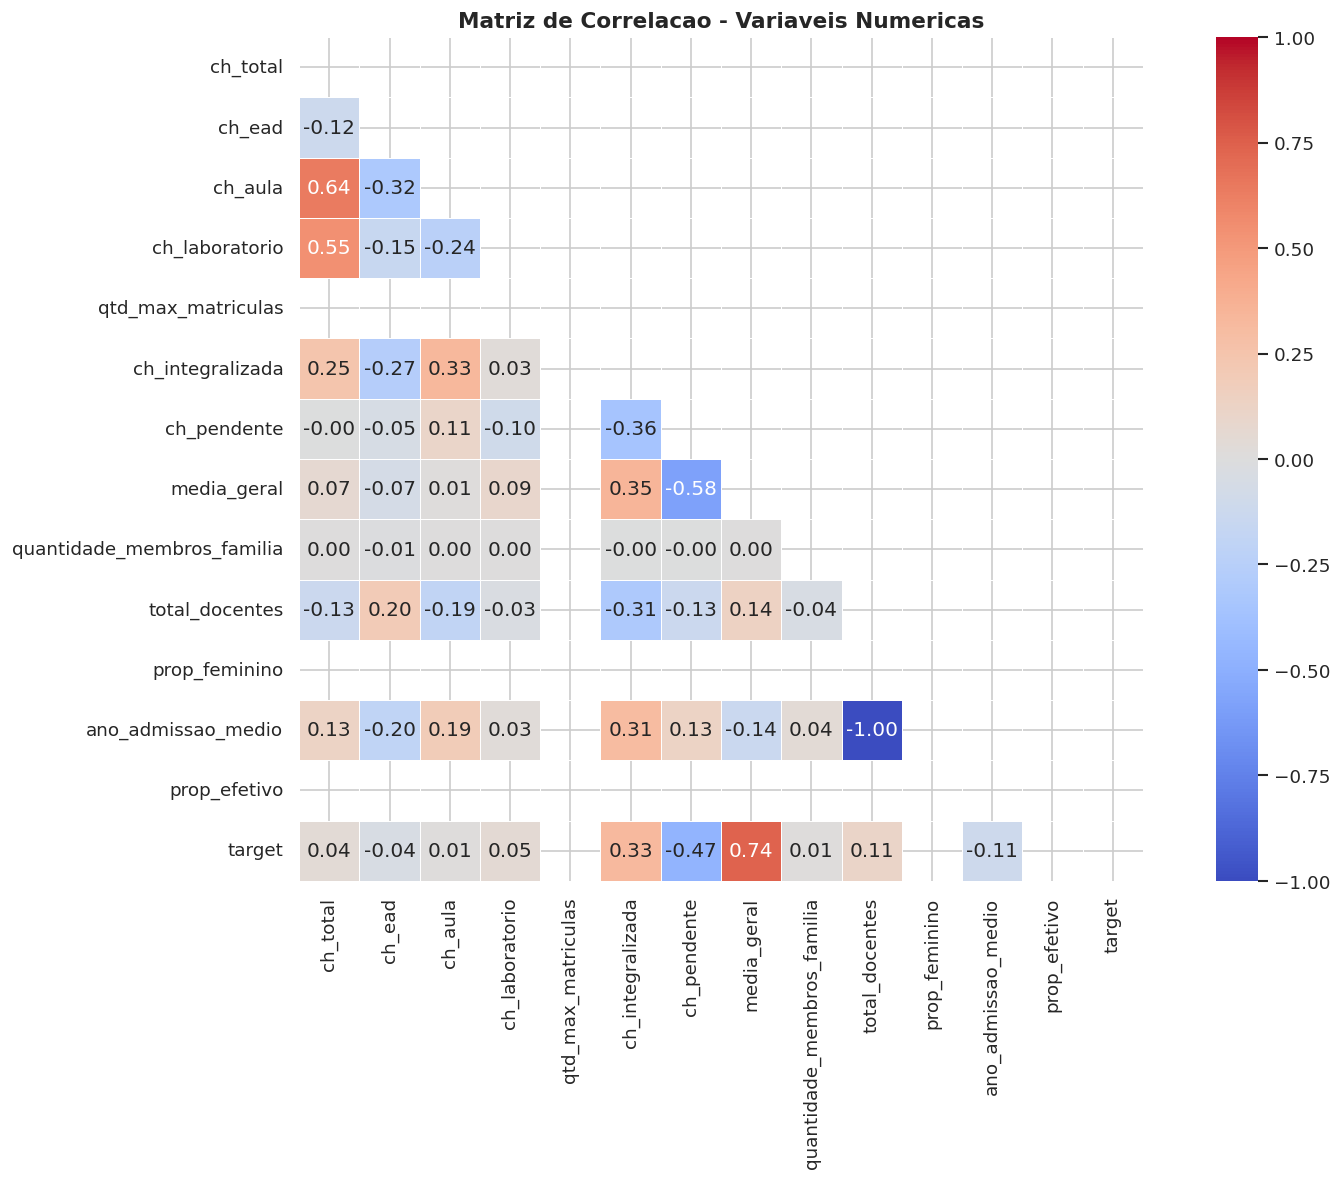

In [20]:
num_corr = [c for c in [
    'ch_total','ch_ead','ch_aula','ch_laboratorio','qtd_max_matriculas',
    'ch_integralizada','ch_pendente','media_geral','quantidade_membros_familia',
    'total_docentes','prop_feminino','ano_admissao_medio','prop_efetivo','target'
] if c in df_modelo.columns]

corr_matrix = df_modelo[num_corr].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Matriz de Correlacao - Variaveis Numericas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pré-processamento e Feature Engineering

In [21]:
FEATURES_ALUNO    = ['sexo','raca_declarada','faixa_renda_familiar','forma_ingresso',
                     'quantidade_membros_familia','ch_integralizada','ch_pendente',
                     'uf_titulo_eleitor_pb','uf_naturalidade_pb']
FEATURES_CURRICULO = ['ch_total','ch_aula','ch_laboratorio','ch_ead',
                      'nivel_componente_curricular','descricao_tipo_componente_curricular',
                      'qtd_max_matriculas','campus','turno']
FEATURES_PROFESSOR = ['total_docentes','prop_feminino','ano_admissao_medio','prop_efetivo']

ALL_FEATURES = [f for f in FEATURES_ALUNO + FEATURES_CURRICULO + FEATURES_PROFESSOR
                if f in df_modelo.columns]

# Feature engineering
if {'ch_ead','ch_total'}.issubset(df_modelo.columns):
    df_modelo['prop_ch_ead'] = df_modelo['ch_ead'] / (df_modelo['ch_total'] + 1e-6)
    ALL_FEATURES.append('prop_ch_ead')
if {'ch_laboratorio','ch_total'}.issubset(df_modelo.columns):
    df_modelo['prop_ch_lab'] = df_modelo['ch_laboratorio'] / (df_modelo['ch_total'] + 1e-6)
    ALL_FEATURES.append('prop_ch_lab')
if {'ch_integralizada','ch_pendente'}.issubset(df_modelo.columns):
    total_ch = df_modelo['ch_integralizada'] + df_modelo['ch_pendente']
    df_modelo['progresso_academico'] = df_modelo['ch_integralizada'] / (total_ch + 1e-6)
    ALL_FEATURES.append('progresso_academico')
if 'ano_ingresso' in df_modelo.columns:
    ALL_FEATURES.append('ano_ingresso')

ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))
print(f'Total features: {len(ALL_FEATURES)}')
print(f'  Aluno: {[f for f in FEATURES_ALUNO if f in ALL_FEATURES]}')
print(f'  Curriculo: {[f for f in FEATURES_CURRICULO if f in ALL_FEATURES]}')
print(f'  Professor: {[f for f in FEATURES_PROFESSOR if f in ALL_FEATURES]}')
print(f'  Engenharia: {[f for f in ALL_FEATURES if f not in FEATURES_ALUNO+FEATURES_CURRICULO+FEATURES_PROFESSOR]}')

Total features: 24
  Aluno: ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'quantidade_membros_familia', 'ch_integralizada', 'ch_pendente', 'uf_titulo_eleitor_pb', 'uf_naturalidade_pb']
  Curriculo: ['ch_total', 'ch_aula', 'ch_laboratorio', 'ch_ead', 'nivel_componente_curricular', 'descricao_tipo_componente_curricular', 'qtd_max_matriculas']
  Professor: ['total_docentes', 'prop_feminino', 'ano_admissao_medio', 'prop_efetivo']
  Engenharia: ['prop_ch_ead', 'prop_ch_lab', 'progresso_academico', 'ano_ingresso']


In [22]:
X = df_modelo[ALL_FEATURES].copy()
y = df_modelo['target'].copy()

FEAT_NUM = X.select_dtypes(include=['number']).columns.tolist()
FEAT_CAT = X.select_dtypes(include=['object','category']).columns.tolist()

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

transformers = [('num', num_pipeline, FEAT_NUM)]
if FEAT_CAT:
    transformers.append(('cat', cat_pipeline, FEAT_CAT))
preprocessor = ColumnTransformer(transformers)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Numericas ({len(FEAT_NUM)}): {FEAT_NUM}')
print(f'Categoricas ({len(FEAT_CAT)}): {FEAT_CAT}')
print(f'Nulos em X: {X.isnull().sum().sum()}')

Treino: 305,791 | Teste: 76,448
Numericas (18): ['quantidade_membros_familia', 'ch_integralizada', 'ch_pendente', 'uf_titulo_eleitor_pb', 'uf_naturalidade_pb', 'ch_total', 'ch_aula', 'ch_laboratorio', 'ch_ead', 'qtd_max_matriculas', 'total_docentes', 'prop_feminino', 'ano_admissao_medio', 'prop_efetivo', 'prop_ch_ead', 'prop_ch_lab', 'progresso_academico', 'ano_ingresso']
Categoricas (6): ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'nivel_componente_curricular', 'descricao_tipo_componente_curricular']
Nulos em X: 6271943


## 7. Modelagem Supervisionada

| Modelo | Justificativa |
|--------|---------------|
| Dummy | Baseline de referencia |
| Regressao Logistica | Linear, interpretavel |
| Arvore de Decisao | Interpretavel, nao-linear |
| Random Forest | Robusto, ensemble |
| Gradient Boosting | Alta performance |
| XGBoost | Estado da arte tabulares |

In [23]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / max(pos, 1)

modelos = {
    'Baseline (Dummy)'   : DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arvore de Decisao'  : DecisionTreeClassifier(max_depth=8, random_state=SEED, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'            : XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos)
}

resultados = []
pipelines_treinados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for nome, modelo in modelos.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', modelo)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(modelo,'predict_proba') else np.zeros(len(y_test))
    cv_sc   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    resultados.append({
        'Modelo'      : nome,
        'Acuracia'    : accuracy_score(y_test, y_pred),
        'Precisao'    : precision_score(y_test, y_pred, zero_division=0),
        'Recall'      : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'    : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'     : roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5,
        'F1-CV Medio' : cv_sc.mean(),
        'F1-CV Std'   : cv_sc.std()
    })
    pipelines_treinados[nome] = pipe
    print(f'{nome:<25} F1={f1_score(y_test,y_pred,zero_division=0):.4f}  AUC={roc_auc_score(y_test,y_proba) if y_proba.sum()>0 else 0.5:.4f}')

df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values('F1-Score', ascending=False).style.highlight_max(
    subset=['Acuracia','Precisao','Recall','F1-Score','AUC-ROC','F1-CV Medio'], color='#b3d9a3'
))

Baseline (Dummy)          F1=0.9104  AUC=0.5000
Regressao Logistica       F1=0.8681  AUC=0.6481
Arvore de Decisao         F1=0.9214  AUC=0.7499
Random Forest             F1=0.9275  AUC=0.7392
Gradient Boosting         F1=0.9322  AUC=0.7503
XGBoost                   F1=0.9263  AUC=0.7586


,Modelo,Acuracia,Precisao,Recall,F1-Score,AUC-ROC,F1-CV Medio,F1-CV Std
4,Gradient Boosting,0.879238,0.878119,0.993330,0.932178,0.750325,0.931226,0.000535
3,Random Forest,0.872462,0.883559,0.975967,0.927467,0.739238,0.926883,0.000564
5,XGBoost,0.871298,0.888016,0.968029,0.926298,0.758570,0.924865,0.000550
2,Arvore de Decisao,0.863397,0.886812,0.958886,0.921442,0.749875,0.917484,0.000904
0,Baseline (Dummy),0.835483,0.835483,1.000000,0.910369,0.500000,0.910364,0.000001
1,Regressao Logistica,0.780033,0.869935,0.866230,0.868079,0.648078,0.866400,0.001337


## 8. Comparação dos Modelos

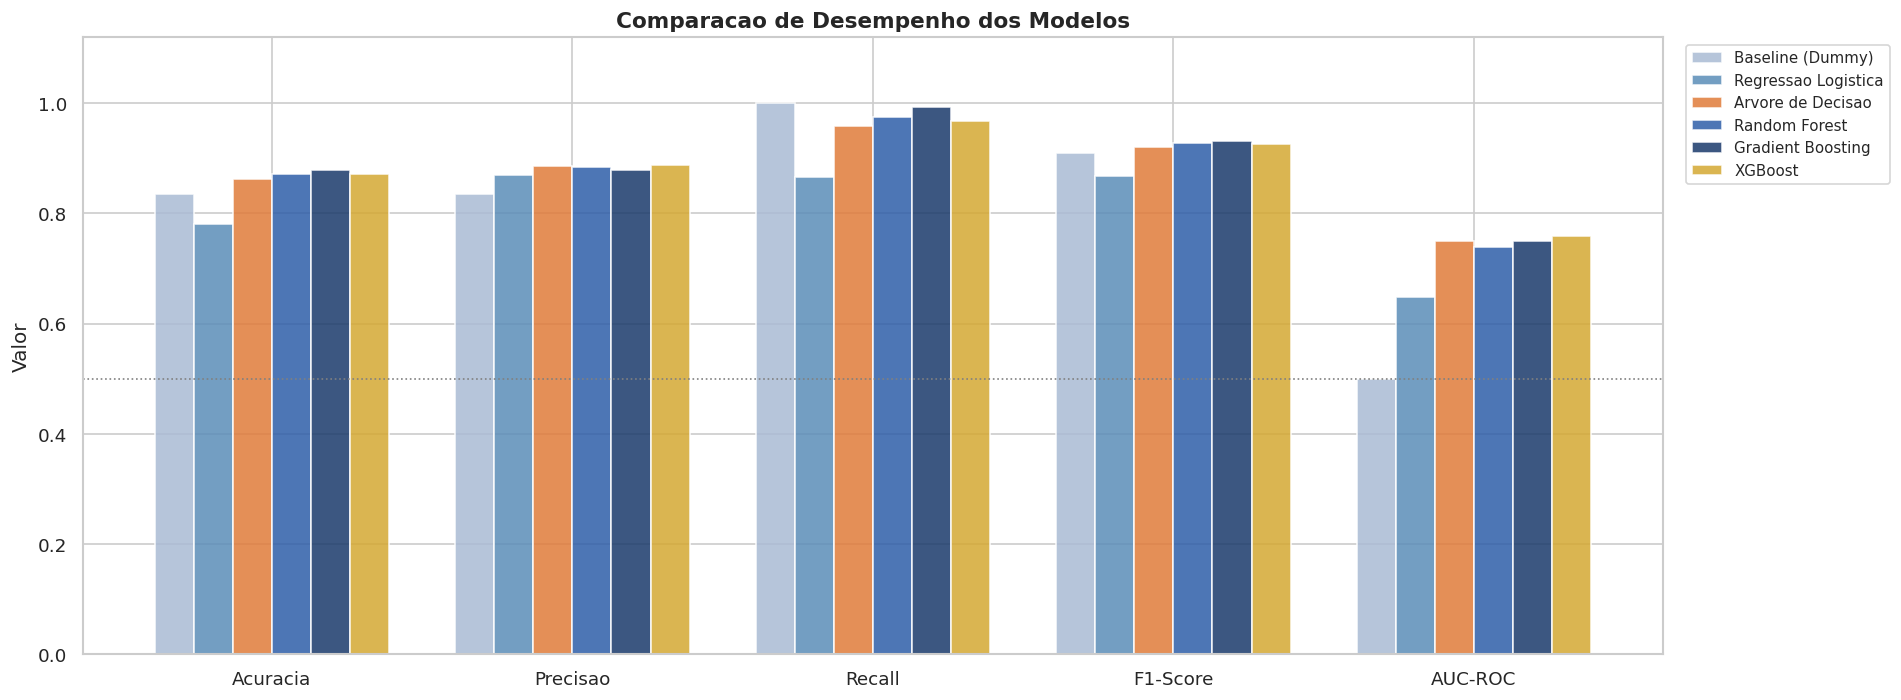

In [24]:
metricas = ['Acuracia','Precisao','Recall','F1-Score','AUC-ROC']
x = np.arange(len(metricas))
width = 0.13
colors_modelos = ['#AABBD4','#5B8DB8','#E07B3A','#2E5EA8','#1A3A6B','#D4A832']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (_, row) in enumerate(df_resultados.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metricas], width,
           label=row['Modelo'], color=colors_modelos[i], alpha=0.85)
ax.set_xticks(x + width*(len(df_resultados)-1)/2)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12); ax.set_ylabel('Valor')
ax.set_title('Comparacao de Desempenho dos Modelos', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', lw=1)
plt.tight_layout()
plt.savefig('fig11_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

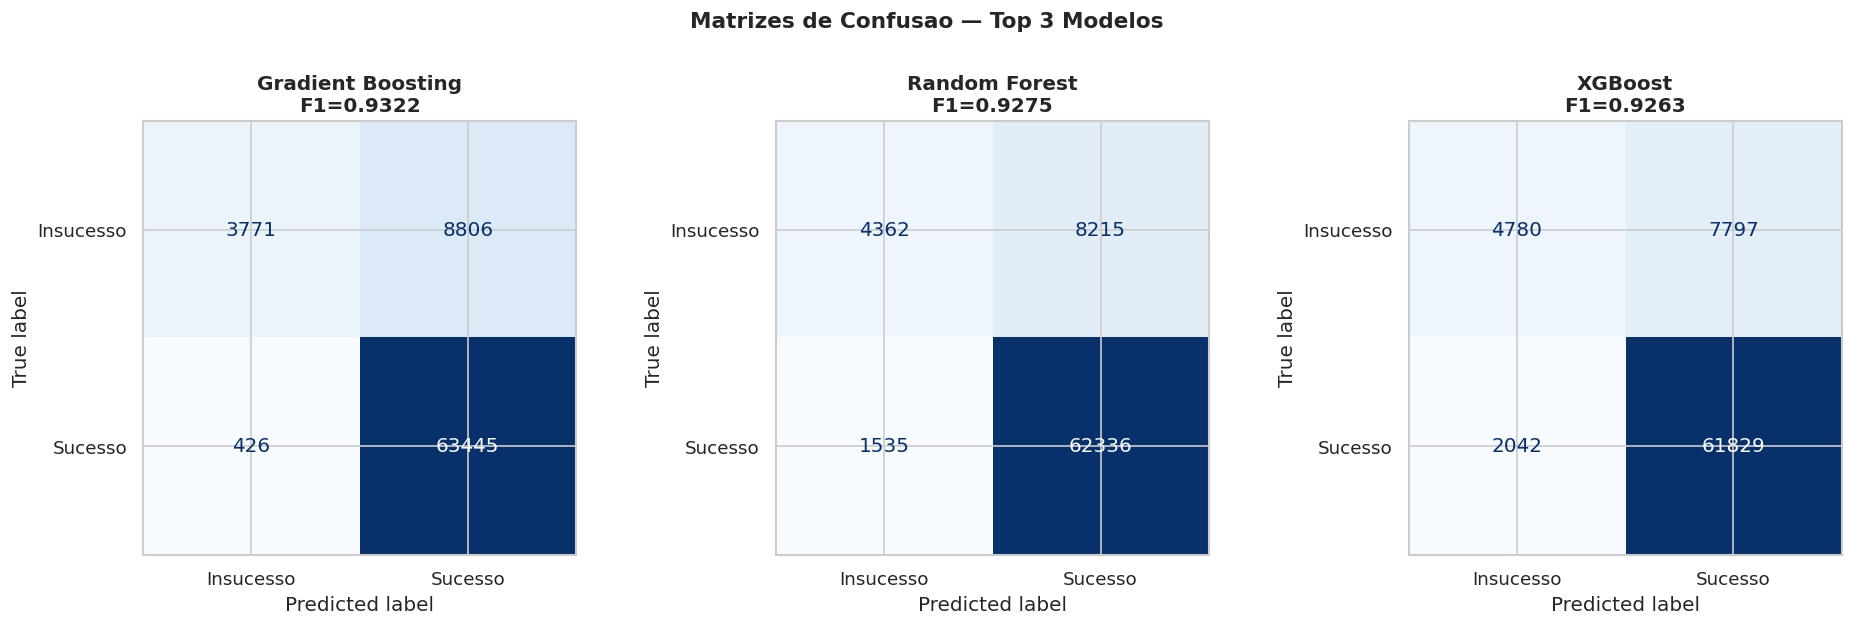

In [25]:
top3 = df_resultados.nlargest(3,'F1-Score')['Modelo'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, nome in zip(axes, top3):
    y_pred = pipelines_treinados[nome].predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Insucesso','Sucesso']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={f1_score(y_test,y_pred,zero_division=0):.4f}', fontweight='bold')
plt.suptitle('Matrizes de Confusao — Top 3 Modelos', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig12_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

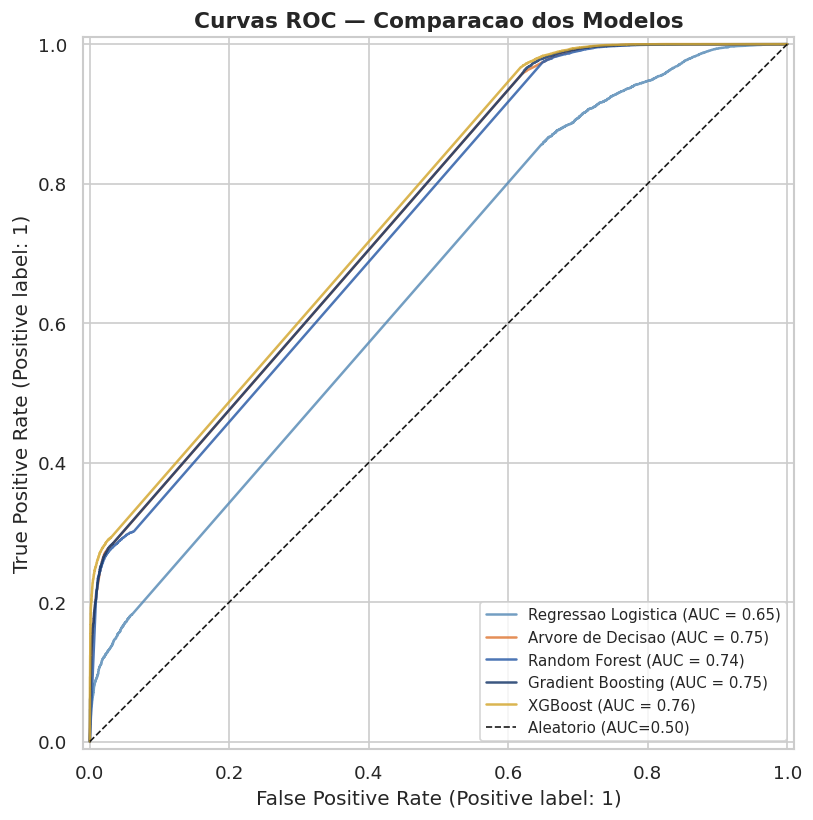

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, (nome, pipe) in enumerate(pipelines_treinados.items()):
    if nome == 'Baseline (Dummy)': continue
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                        name=nome, color=colors_modelos[i], alpha=0.85)
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_title('Curvas ROC — Comparacao dos Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig13_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

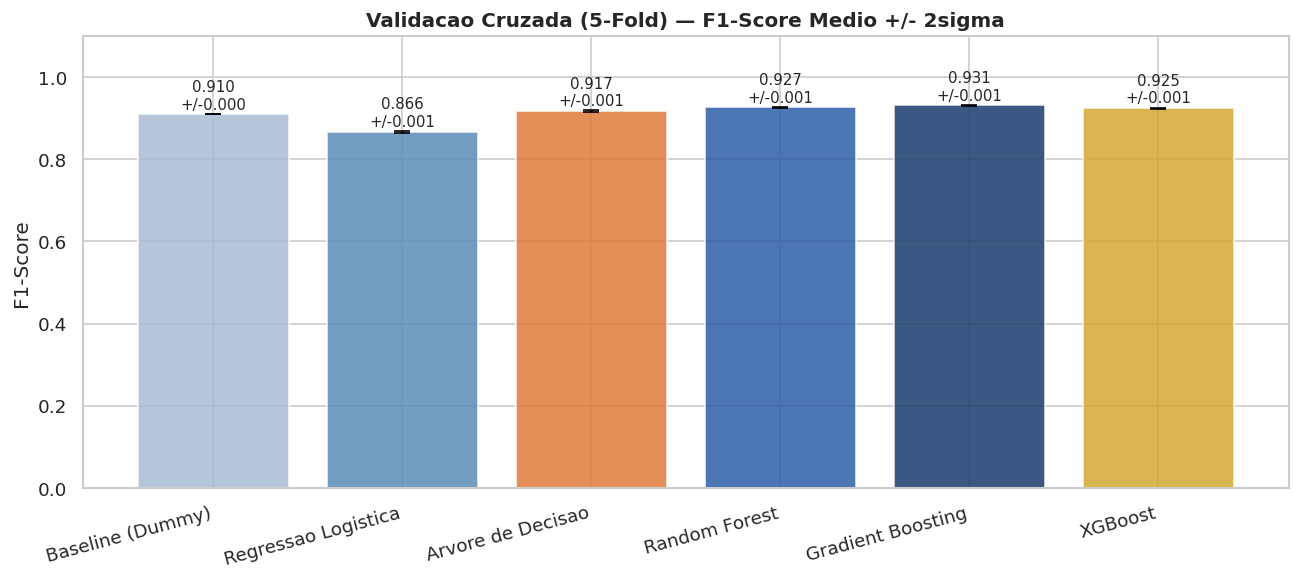

Melhor modelo: Gradient Boosting
              precision    recall  f1-score   support

   Insucesso       0.90      0.30      0.45     12577
     Sucesso       0.88      0.99      0.93     63871

    accuracy                           0.88     76448
   macro avg       0.89      0.65      0.69     76448
weighted avg       0.88      0.88      0.85     76448



In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
nomes  = df_resultados['Modelo']
medias = df_resultados['F1-CV Medio']
stds   = df_resultados['F1-CV Std']
bars = ax.bar(nomes, medias, color=colors_modelos[:len(nomes)], alpha=0.85)
ax.errorbar(nomes, medias, yerr=stds*2, fmt='none', color='black', capsize=5, lw=2)
for bar, val, std in zip(bars, medias, stds):
    ax.text(bar.get_x()+bar.get_width()/2, val+std*2+0.005,
            f'{val:.3f}\n+/-{std:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_title('Validacao Cruzada (5-Fold) — F1-Score Medio +/- 2sigma', fontweight='bold')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

melhor = df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']
print(f'Melhor modelo: {melhor}')
print(classification_report(y_test, pipelines_treinados[melhor].predict(X_test),
                             target_names=['Insucesso','Sucesso']))

## 9. Interpretabilidade — Importância das Variáveis

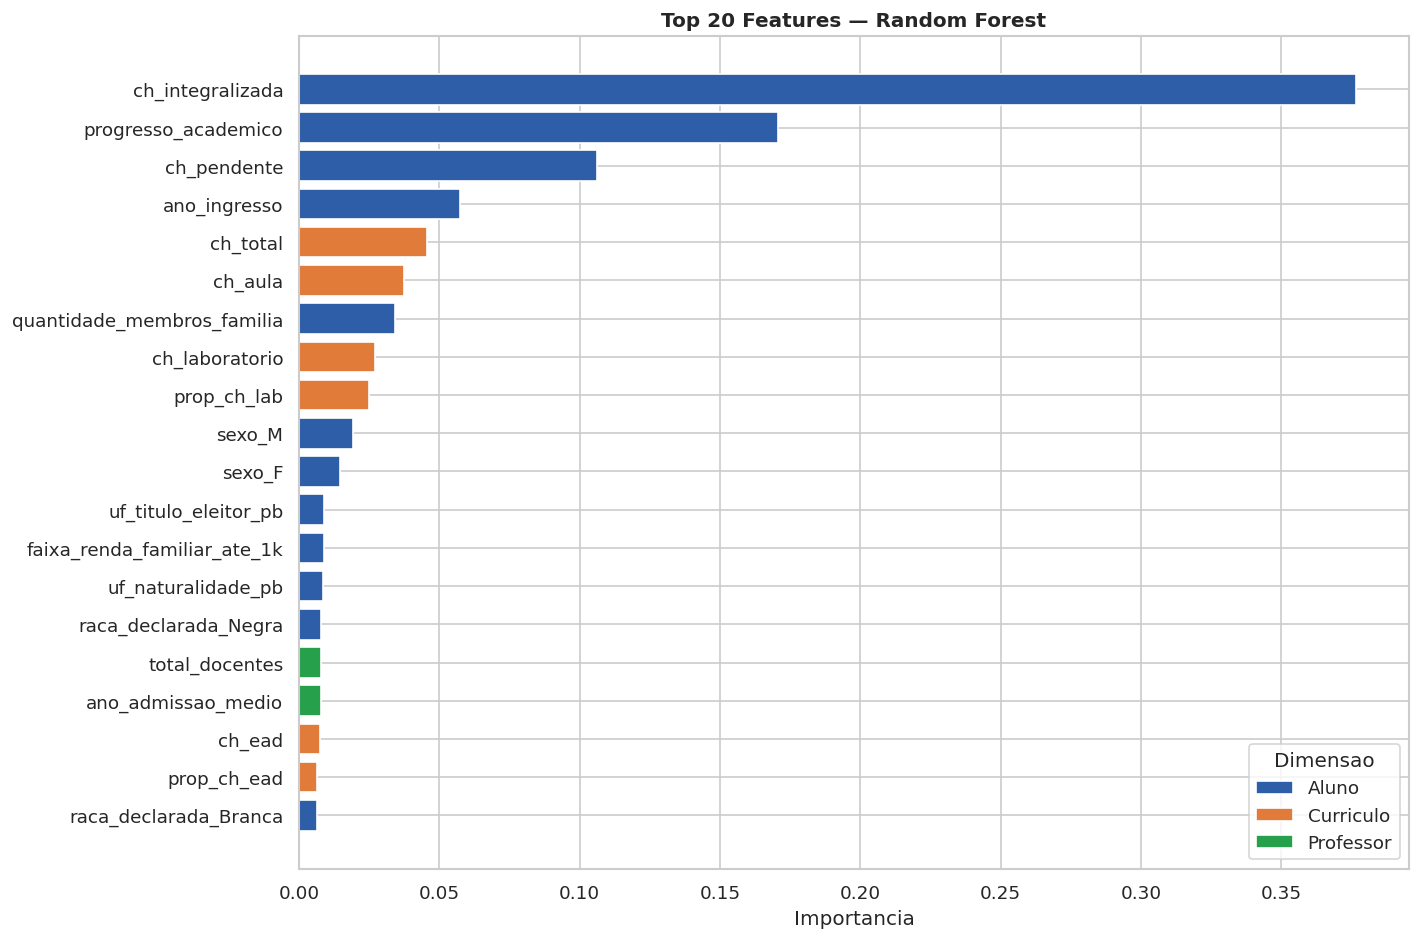


Top 10 features (Random Forest):
  [Aluno     ] ch_integralizada                         0.3767
  [Aluno     ] progresso_academico                      0.1707
  [Aluno     ] ch_pendente                              0.1062
  [Aluno     ] ano_ingresso                             0.0575
  [Curriculo ] ch_total                                 0.0456
  [Curriculo ] ch_aula                                  0.0375
  [Aluno     ] quantidade_membros_familia               0.0343
  [Curriculo ] ch_laboratorio                           0.0269
  [Curriculo ] prop_ch_lab                              0.0248
  [Aluno     ] sexo_M                                   0.0190


In [28]:
modelos_arvore = ['Random Forest','XGBoost','Gradient Boosting','Arvore de Decisao']
nome_imp = next((m for m in modelos_arvore if m in pipelines_treinados), None)

if nome_imp:
    pipe_imp = pipelines_treinados[nome_imp]
    clf = pipe_imp.named_steps['classifier']
    prep = pipe_imp.named_steps['preprocessor']

    feat_names_all = FEAT_NUM.copy()
    if FEAT_CAT and 'cat' in prep.named_transformers_:
        ohe = prep.named_transformers_['cat'].named_steps['encoder']
        feat_names_all += list(ohe.get_feature_names_out(FEAT_CAT))

    df_imp = pd.DataFrame({'feature': feat_names_all, 'importancia': clf.feature_importances_})
    df_imp = df_imp.sort_values('importancia', ascending=False).head(20)

    def get_bloco(feat):
        f = feat.lower()
        if any(k in f for k in ['sexo','raca','renda','ingresso','familia','ch_integr','ch_pend','media_g','uf_','progress']):
            return 'Aluno'
        if any(k in f for k in ['ch_total','ch_aula','ch_lab','ch_ead','nivel','tipo_comp','qtd_max','campus','turno','prop_ch']):
            return 'Curriculo'
        if any(k in f for k in ['docentes','feminino','admissao','efetivo']):
            return 'Professor'
        return 'Outro'

    df_imp['bloco'] = df_imp['feature'].apply(get_bloco)
    bcolors = {'Aluno':'#2E5EA8','Curriculo':'#E07B3A','Professor':'#27A04B','Outro':'#888'}

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(df_imp['feature'][::-1], df_imp['importancia'][::-1],
            color=[bcolors[b] for b in df_imp['bloco']][::-1])
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 20 Features — {nome_imp}', fontweight='bold')
    ax.legend(handles=[Patch(facecolor=c, label=b) for b,c in bcolors.items()
                       if b in df_imp['bloco'].values], title='Dimensao')
    plt.tight_layout()
    plt.savefig('fig15_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop 10 features ({nome_imp}):')
    for _, row in df_imp.head(10).iterrows():
        print(f'  [{row["bloco"]:10}] {row["feature"]:40} {row["importancia"]:.4f}')

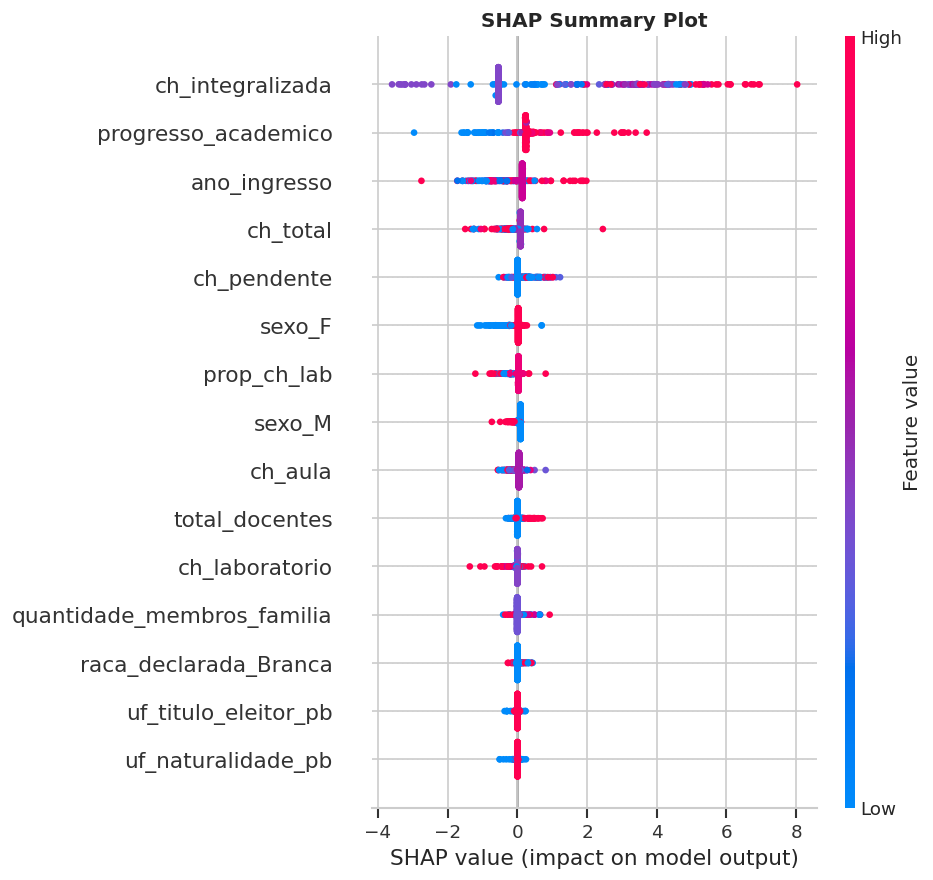

SHAP calculado com sucesso!


In [29]:
try:
    import shap
    pipe_shap = pipelines_treinados.get('XGBoost') or pipelines_treinados.get('Random Forest')
    X_shap = pipe_shap.named_steps['preprocessor'].transform(X_test)[:500]
    explainer   = shap.TreeExplainer(pipe_shap.named_steps['classifier'])
    shap_values = explainer.shap_values(X_shap)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(11, 8))
    shap.summary_plot(shap_vals, X_shap, feature_names=feat_names_all, max_display=15, show=False)
    plt.title('SHAP Summary Plot', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig16_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP calculado com sucesso!')
except ImportError:
    print('SHAP nao instalado. Execute: pip install shap')
except Exception as e:
    print(f'SHAP indisponivel: {e}')

## 10. Conclusões Parciais e Próximos Passos

In [30]:
print('=' * 70)
print(' SUMARIO DOS RESULTADOS — ENTREGA PARCIAL')
print('=' * 70)
print(f'\nDataset integrado: {len(df_modelo):,} registros | {len(ALL_FEATURES)} features')
print('3 dimensoes: Aluno, Curriculo, Professor')
print('Variavel-alvo: Binaria (Sucesso / Insucesso)')
print('\nRanking dos modelos (F1-Score):')
df_rank = df_resultados[['Modelo','Acuracia','F1-Score','AUC-ROC','F1-CV Medio']]\
              .sort_values('F1-Score', ascending=False).reset_index(drop=True)
for idx, row in df_rank.iterrows():
    print(f'  {idx+1}. {row["Modelo"]:<25} F1={row["F1-Score"]:.4f}  AUC={row["AUC-ROC"]:.4f}  CV={row["F1-CV Medio"]:.4f}')

print('\nPrincipais observacoes EDA:')
print('  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso')
print('  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)')
print('  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao')
print('  - Departamentos diferem substancialmente em taxa de aprovacao')
print('  - media_geral e ch_integralizada sao os preditores mais fortes do perfil do aluno')

print('\nProximos passos (entrega final):')
print('  1. Otimizacao de hiperparametros (GridSearchCV / Optuna)')
print('  2. Tratamento de desbalanceamento (SMOTE)')
print('  3. Analise SHAP completa por dimensao')
print('  4. Validacao temporal (treinar em anos anteriores, testar no mais recente)')
print('  5. Analise de evasao como segunda variavel-alvo')
print('  6. Dashboard interativo com predicao em tempo real')

 SUMARIO DOS RESULTADOS — ENTREGA PARCIAL

Dataset integrado: 382,239 registros | 24 features
3 dimensoes: Aluno, Curriculo, Professor
Variavel-alvo: Binaria (Sucesso / Insucesso)

Ranking dos modelos (F1-Score):
  1. Gradient Boosting         F1=0.9322  AUC=0.7503  CV=0.9312
  2. Random Forest             F1=0.9275  AUC=0.7392  CV=0.9269
  3. XGBoost                   F1=0.9263  AUC=0.7586  CV=0.9249
  4. Arvore de Decisao         F1=0.9214  AUC=0.7499  CV=0.9175
  5. Baseline (Dummy)          F1=0.9104  AUC=0.5000  CV=0.9104
  6. Regressao Logistica       F1=0.8681  AUC=0.6481  CV=0.8664

Principais observacoes EDA:
  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso
  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)
  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao
  - Departamentos diferem substancialmente em taxa de aprovacao
  - media_geral e ch_integralizada sao os predit

In [33]:
!git config --global user.name "isabwllyrr"
!git config --global user.email "itsbellyrr@gmail.com"

!git clone https://github.com/mcarolina2/analise-preditiva-desempenho-academico.git

%cd analise-preditiva-desempenho-academico

Cloning into 'analise-preditiva-desempenho-academico'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
/content/analise-preditiva-desempenho-academico


In [35]:
!ls /content

analise-preditiva-desempenho-academico	fig1_taxa_sucesso_perfil_aluno.png
componentes.parquet			fig2_forma_ingresso.png
cursos.parquet				fig3_distribuicoes_numericas.png
discentes.parquet			fig4_evolucao_temporal.png
docentes.parquet			fig5_taxa_sucesso_curriculo.png
fig10_correlacao.png			fig6_ch_vs_taxa.png
fig11_comparacao_modelos.png		fig7_taxa_departamento.png
fig12_matrizes_confusao.png		fig8_perfil_docente.png
fig13_curvas_roc.png			fig9_analise_alvo.png
fig14_cross_validation.png		matriculas.parquet
fig15_feature_importance.png		sample_data
fig16_shap_summary.png
